Project root: /Users/mac/Desktop/DSS5104_Assignment2
Using device: cpu
PaySim features: 6
Features: ['is_high_risk_type', 'balance_diff_orig', 'orig_balance_zero', 'amt_to_balance_ratio', 'orig_tx_count', 'orig_amt_mean']

Train shape: (5090096, 17)
Test shape: (1272524, 17)
Train fraud rate: 0.000778
Test fraud rate: 0.003343

X_train shape: (5090096, 6)
X_test shape: (1272524, 6)
X_train shape after scaling: (5090096, 6)
X_test shape after scaling: (1272524, 6)

Input dimension: 6

Training: Semi-supervised Autoencoder on PaySim
Semi-supervised mode: 5,086,137 normal samples

Training encoding dimension 8 (1/3)
  Epoch 20/80, Loss: 0.115254, Val Loss: 0.048460
  Epoch 40/80, Loss: 0.091737, Val Loss: 0.046087

Training encoding dimension 16 (2/3)
  Epoch 20/80, Loss: 0.113966, Val Loss: 0.094734

Training encoding dimension 32 (3/3)
  Epoch 20/80, Loss: 0.123937, Val Loss: 0.456987
  Epoch 40/80, Loss: 0.105460, Val Loss: 0.050506

Test Results (Semi-supervised Autoencoder on PaySim)

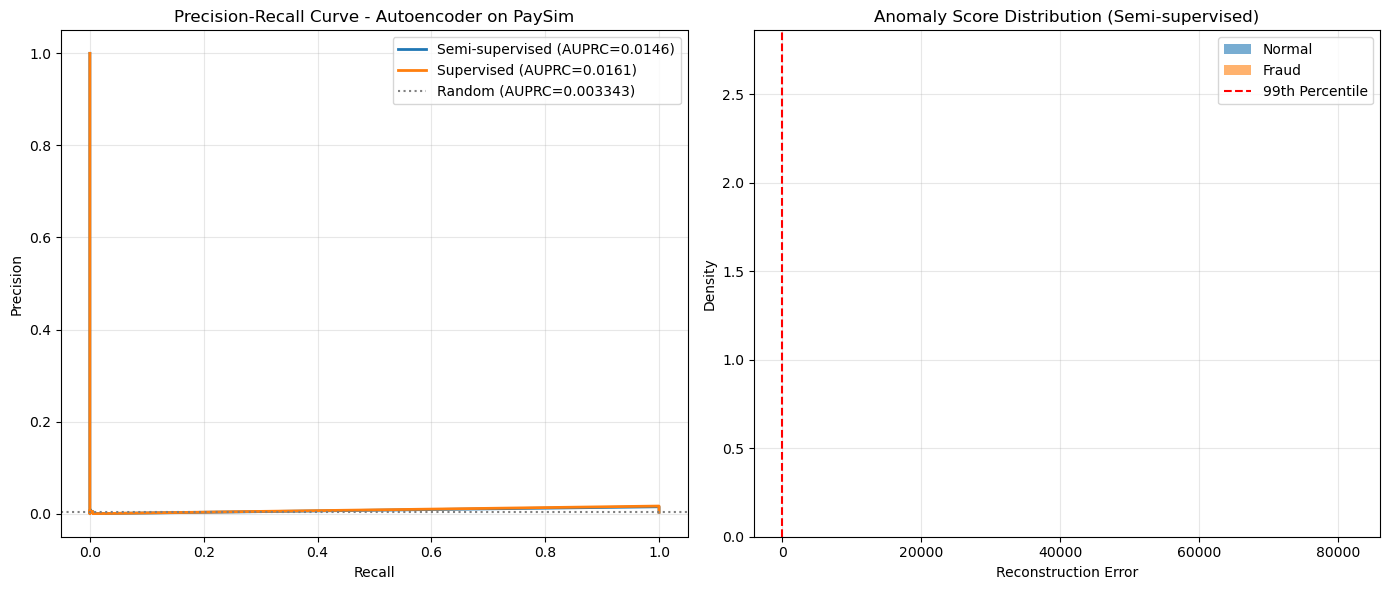


Results Summary - Autoencoder on PaySim
                      Model    AUPRC  ROC AUC Cost-Optimal Threshold Min Total Cost
Semi-supervised Autoencoder 0.014645 0.785197                 0.0000    $555,134.00
     Supervised Autoencoder 0.016075 0.803533                 0.0000    $503,420.00


In [1]:
# Autoencoder for PaySim Fraud Detection
# Secondary Dataset Validation

import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import (
    average_precision_score, roc_auc_score, 
    precision_recall_curve, precision_score, 
    recall_score, f1_score
)

# Set project root
try:
    current_dir = Path.cwd()
    if (current_dir / 'src').exists():
        PROJECT_ROOT = current_dir
    elif (current_dir.parent / 'src').exists():
        PROJECT_ROOT = current_dir.parent
    else:
        PROJECT_ROOT = Path.cwd().parent
except Exception:
    PROJECT_ROOT = Path.cwd()

print(f"Project root: {PROJECT_ROOT}")

torch.manual_seed(42)
np.random.seed(42)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

def load_paysim_data():
    """Load PaySim data from processed folder"""
    data_dir = PROJECT_ROOT / 'data' / 'processed'
    
    train = pd.read_parquet(data_dir / 'paysim_train.parquet')
    test = pd.read_parquet(data_dir / 'paysim_test.parquet')
    
    with open(data_dir / 'dataset_info.json', 'r') as f:
        info = json.load(f)
    
    features = info['paysim']['engineered_features']
    
    return train, test, features

# Load PaySim data
train_paysim, test_paysim, paysim_features = load_paysim_data()

print(f"PaySim features: {len(paysim_features)}")
print(f"Features: {paysim_features}")
print(f"\nTrain shape: {train_paysim.shape}")
print(f"Test shape: {test_paysim.shape}")
print(f"Train fraud rate: {train_paysim['isFraud'].mean():.6f}")
print(f"Test fraud rate: {test_paysim['isFraud'].mean():.6f}")

# ============================================================
# 1. Feature Preparation
# ============================================================

X_train_raw = train_paysim[paysim_features].values
X_test_raw = test_paysim[paysim_features].values
y_train = train_paysim['isFraud'].values
y_test = test_paysim['isFraud'].values

print(f"\nX_train shape: {X_train_raw.shape}")
print(f"X_test shape: {X_test_raw.shape}")

# Handle missing values (if any)
if np.isnan(X_train_raw).sum() > 0:
    print(f"Filling {np.isnan(X_train_raw).sum()} missing values...")
    for i in range(X_train_raw.shape[1]):
        col_median = np.nanmedian(X_train_raw[:, i])
        X_train_raw[np.isnan(X_train_raw[:, i]), i] = col_median
        X_test_raw[np.isnan(X_test_raw[:, i]), i] = col_median

# Standardize
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train_raw)
X_test = scaler.transform(X_test_raw)

print(f"X_train shape after scaling: {X_train.shape}")
print(f"X_test shape after scaling: {X_test.shape}")

# ============================================================
# 2. Define Autoencoder Model
# ============================================================

class Autoencoder(nn.Module):
    def __init__(self, input_dim, encoding_dim=16, hidden_dims=[64, 32]):
        super(Autoencoder, self).__init__()
        
        encoder_layers = []
        prev_dim = input_dim
        for h_dim in hidden_dims:
            encoder_layers.append(nn.Linear(prev_dim, h_dim))
            encoder_layers.append(nn.BatchNorm1d(h_dim))
            encoder_layers.append(nn.ReLU())
            encoder_layers.append(nn.Dropout(0.2))
            prev_dim = h_dim
        encoder_layers.append(nn.Linear(prev_dim, encoding_dim))
        self.encoder = nn.Sequential(*encoder_layers)
        
        decoder_layers = []
        prev_dim = encoding_dim
        for h_dim in reversed(hidden_dims):
            decoder_layers.append(nn.Linear(prev_dim, h_dim))
            decoder_layers.append(nn.BatchNorm1d(h_dim))
            decoder_layers.append(nn.ReLU())
            decoder_layers.append(nn.Dropout(0.2))
            prev_dim = h_dim
        decoder_layers.append(nn.Linear(prev_dim, input_dim))
        self.decoder = nn.Sequential(*decoder_layers)
    
    def forward(self, x):
        encoded = self.encoder(x)
        decoded = self.decoder(encoded)
        return decoded
    
    def get_reconstruction_error(self, x):
        with torch.no_grad():
            reconstructed = self.forward(x)
            mse = ((x - reconstructed) ** 2).mean(dim=1)
        return mse.cpu().numpy()


class EnsembleAutoencoder:
    def __init__(self, input_dim, encoding_dims=[8, 16, 32]):
        self.input_dim = input_dim
        self.encoding_dims = encoding_dims
        self.models = []
    
    def _train_single(self, X_train, encoding_dim, epochs=100, batch_size=2048, verbose=True):
        val_size = int(len(X_train) * 0.1)
        X_train_sub = torch.FloatTensor(X_train[:-val_size]).to(device)
        X_val = torch.FloatTensor(X_train[-val_size:]).to(device)
        
        train_dataset = TensorDataset(X_train_sub, X_train_sub)
        train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
        
        model = Autoencoder(self.input_dim, encoding_dim=encoding_dim).to(device)
        optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-5)
        scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=10)
        criterion = nn.MSELoss()
        
        best_val_loss = float('inf')
        patience_counter = 0
        
        for epoch in range(epochs):
            model.train()
            epoch_loss = 0
            for batch_X, _ in train_loader:
                optimizer.zero_grad()
                outputs = model(batch_X)
                loss = criterion(outputs, batch_X)
                loss.backward()
                optimizer.step()
                epoch_loss += loss.item() * batch_X.size(0)
            
            epoch_loss /= len(X_train_sub)
            
            model.eval()
            with torch.no_grad():
                val_outputs = model(X_val)
                val_loss = criterion(val_outputs, X_val).item()
            
            scheduler.step(val_loss)
            
            if val_loss < best_val_loss:
                best_val_loss = val_loss
                patience_counter = 0
                best_state = model.state_dict().copy()
            else:
                patience_counter += 1
            
            if patience_counter >= 15:
                break
            
            if verbose and (epoch + 1) % 20 == 0:
                print(f"  Epoch {epoch+1}/{epochs}, Loss: {epoch_loss:.6f}, Val Loss: {val_loss:.6f}")
        
        model.load_state_dict(best_state)
        return model
    
    def fit(self, X_train, y_train, mode='semi_supervised', epochs=100, batch_size=2048, verbose=True):
        if mode == 'semi_supervised':
            normal_idx = (y_train == 0)
            X_train_selected = X_train[normal_idx]
            print(f"Semi-supervised mode: {len(X_train_selected):,} normal samples")
        else:
            X_train_selected = X_train
            print(f"Supervised mode: {len(X_train_selected):,} all samples")
        
        self.models = []
        for i, enc_dim in enumerate(self.encoding_dims):
            print(f"\nTraining encoding dimension {enc_dim} ({i+1}/{len(self.encoding_dims)})")
            model = self._train_single(X_train_selected, enc_dim, epochs, batch_size, verbose)
            self.models.append(model)
        
        return self
    
    def predict_anomaly_scores(self, X):
        X_tensor = torch.FloatTensor(X).to(device)
        all_scores = []
        for model in self.models:
            model.eval()
            scores = model.get_reconstruction_error(X_tensor)
            all_scores.append(scores)
        return np.mean(all_scores, axis=0)


# ============================================================
# 3. Train on PaySim
# ============================================================

input_dim = X_train.shape[1]
print(f"\nInput dimension: {input_dim}")

print("\n" + "="*60)
print("Training: Semi-supervised Autoencoder on PaySim")
print("="*60)

ensemble_semi = EnsembleAutoencoder(input_dim, encoding_dims=[8, 16, 32])
ensemble_semi.fit(X_train, y_train, mode='semi_supervised', epochs=80, batch_size=2048, verbose=True)

test_scores_semi = ensemble_semi.predict_anomaly_scores(X_test)

auprc_semi = average_precision_score(y_test, test_scores_semi)
roc_auc_semi = roc_auc_score(y_test, test_scores_semi)

print(f"\nTest Results (Semi-supervised Autoencoder on PaySim):")
print(f"  AUPRC: {auprc_semi:.4f}")
print(f"  ROC AUC: {roc_auc_semi:.4f}")

print("\n" + "="*60)
print("Training: Supervised Autoencoder on PaySim")
print("="*60)

ensemble_sup = EnsembleAutoencoder(input_dim, encoding_dims=[8, 16, 32])
ensemble_sup.fit(X_train, y_train, mode='supervised', epochs=80, batch_size=2048, verbose=True)

test_scores_sup = ensemble_sup.predict_anomaly_scores(X_test)

auprc_sup = average_precision_score(y_test, test_scores_sup)
roc_auc_sup = roc_auc_score(y_test, test_scores_sup)

print(f"\nTest Results (Supervised Autoencoder on PaySim):")
print(f"  AUPRC: {auprc_sup:.4f}")
print(f"  ROC AUC: {roc_auc_sup:.4f}")

# ============================================================
# 4. Cost-Sensitive Evaluation
# ============================================================

def normalize_scores(scores):
    scores_min = scores.min()
    scores_max = scores.max()
    if scores_max - scores_min > 0:
        return (scores - scores_min) / (scores_max - scores_min)
    return scores

test_scores_semi_norm = normalize_scores(test_scores_semi)
test_scores_sup_norm = normalize_scores(test_scores_sup)

def find_cost_optimal_threshold(y_true, y_scores, fn_cost=500, fp_cost=2):
    precision, recall, thresholds = precision_recall_curve(y_true, y_scores)
    costs = []
    f1_scores = []
    
    for t in thresholds:
        y_pred = (y_scores >= t).astype(int)
        tp = np.sum((y_true == 1) & (y_pred == 1))
        fp = np.sum((y_true == 0) & (y_pred == 1))
        fn = np.sum((y_true == 1) & (y_pred == 0))
        total_cost = fn * fn_cost + fp * fp_cost
        costs.append(total_cost)
        p = tp / (tp + fp + 1e-9)
        r = tp / (tp + fn + 1e-9)
        f1_scores.append(2 * p * r / (p + r + 1e-9) if (p + r) > 0 else 0)
    
    best_idx = np.argmin(costs)
    best_threshold = thresholds[best_idx]
    min_cost = costs[best_idx]
    f1_best_idx = np.argmax(f1_scores)
    f1_optimal_threshold = thresholds[f1_best_idx]
    
    return best_threshold, min_cost, f1_optimal_threshold, thresholds, costs, f1_scores

cost_threshold_semi, min_cost_semi, f1_threshold_semi, thresholds_semi, costs_semi, f1_scores_semi = find_cost_optimal_threshold(
    y_test, test_scores_semi_norm, fn_cost=500, fp_cost=2
)

cost_threshold_sup, min_cost_sup, f1_threshold_sup, thresholds_sup, costs_sup, f1_scores_sup = find_cost_optimal_threshold(
    y_test, test_scores_sup_norm, fn_cost=500, fp_cost=2
)

print("\n" + "="*60)
print("Cost-Sensitive Evaluation on PaySim (FN=$500, FP=$2)")
print("="*60)
print(f"\nSemi-supervised Autoencoder:")
print(f"  Cost-optimal threshold: {cost_threshold_semi:.4f}")
print(f"  F1-optimal threshold: {f1_threshold_semi:.4f}")
print(f"  Minimum total cost: ${min_cost_semi:,.2f}")

print(f"\nSupervised Autoencoder:")
print(f"  Cost-optimal threshold: {cost_threshold_sup:.4f}")
print(f"  F1-optimal threshold: {f1_threshold_sup:.4f}")
print(f"  Minimum total cost: ${min_cost_sup:,.2f}")

# ============================================================
# 5. Evaluation at Cost-Optimal Threshold
# ============================================================

y_pred_semi = (test_scores_semi_norm > cost_threshold_semi).astype(int)
y_pred_sup = (test_scores_sup_norm > cost_threshold_sup).astype(int)

print("\n" + "="*60)
print(f"Evaluation at Cost-Optimal Threshold on PaySim")
print("="*60)

print(f"\nSemi-supervised Autoencoder (threshold={cost_threshold_semi:.4f}):")
print(f"  AUPRC: {auprc_semi:.4f}")
print(f"  Precision: {precision_score(y_test, y_pred_semi):.4f}")
print(f"  Recall: {recall_score(y_test, y_pred_semi):.4f}")
print(f"  F1: {f1_score(y_test, y_pred_semi):.4f}")

print(f"\nSupervised Autoencoder (threshold={cost_threshold_sup:.4f}):")
print(f"  AUPRC: {auprc_sup:.4f}")
print(f"  Precision: {precision_score(y_test, y_pred_sup):.4f}")
print(f"  Recall: {recall_score(y_test, y_pred_sup):.4f}")
print(f"  F1: {f1_score(y_test, y_pred_sup):.4f}")

# ============================================================
# 6. Visualization
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# PR Curves
precision_semi, recall_semi, _ = precision_recall_curve(y_test, test_scores_semi_norm)
precision_sup, recall_sup, _ = precision_recall_curve(y_test, test_scores_sup_norm)

axes[0].plot(recall_semi, precision_semi, linewidth=2, 
             label=f'Semi-supervised (AUPRC={auprc_semi:.4f})')
axes[0].plot(recall_sup, precision_sup, linewidth=2,
             label=f'Supervised (AUPRC={auprc_sup:.4f})')
axes[0].axhline(y=y_test.mean(), color='gray', linestyle=':', linewidth=1.5,
                label=f'Random (AUPRC={y_test.mean():.6f})')
axes[0].set_xlabel('Recall')
axes[0].set_ylabel('Precision')
axes[0].set_title('Precision-Recall Curve - Autoencoder on PaySim')
axes[0].legend(loc='upper right')
axes[0].grid(True, alpha=0.3)

# Anomaly Score Distribution
axes[1].hist(test_scores_semi[y_test==0], bins=50, alpha=0.6, label='Normal', density=True)
axes[1].hist(test_scores_semi[y_test==1], bins=50, alpha=0.6, label='Fraud', density=True)
threshold_99 = np.percentile(test_scores_semi[y_test==0], 99)
axes[1].axvline(x=threshold_99, color='red', linestyle='--', label=f'99th Percentile')
axes[1].set_xlabel('Reconstruction Error')
axes[1].set_ylabel('Density')
axes[1].set_title('Anomaly Score Distribution (Semi-supervised)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(PROJECT_ROOT / 'data/processed' / 'autoencoder_paysim_results.png', dpi=150, bbox_inches='tight')
plt.show()

# ============================================================
# 7. Save Results
# ============================================================

results_dir = PROJECT_ROOT / 'data/processed/dl_results'
results_dir.mkdir(parents=True, exist_ok=True)

# Save scores for final evaluation
pd.DataFrame({
    'y_true': y_test,
    'autoencoder_semi_score': test_scores_semi_norm,
    'autoencoder_sup_score': test_scores_sup_norm
}).to_csv(results_dir / 'autoencoder_scores_paysim.csv', index=False)

# Results summary
results_summary = pd.DataFrame({
    'Model': ['Semi-supervised Autoencoder', 'Supervised Autoencoder'],
    'AUPRC': [auprc_semi, auprc_sup],
    'ROC AUC': [roc_auc_semi, roc_auc_sup],
    'Cost-Optimal Threshold': [f"{cost_threshold_semi:.4f}", f"{cost_threshold_sup:.4f}"],
    'Min Total Cost': [f"${min_cost_semi:,.2f}", f"${min_cost_sup:,.2f}"]
})

print("\n" + "="*60)
print("Results Summary - Autoencoder on PaySim")
print("="*60)
print(results_summary.to_string(index=False))
